# Data + Baseline Model
**Dataset:** SMS Spam Collection Dataset  
**Task:** Binary Text Classification — Spam vs Ham

## 1. Dataset Description

The **SMS Spam Collection Dataset** is a labeled dataset of 5,572 English SMS messages collected from various sources. Each message is tagged as either:
- **ham** — legitimate (non-spam) message
- **spam** — unsolicited/junk message

| Property | Value |
|---|---|
| Total samples | 5,572 |
| Ham messages | 4,825 (86.6%) |
| Spam messages | 747 (13.4%) |
| Language | English |
| Task | Binary Classification |

The dataset is **imbalanced** — ham messages are ~6.5× more common than spam.

## 2. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
import warnings
warnings.filterwarnings('ignore')

print('All libraries imported successfully.')

All libraries imported successfully.


## 3. Load the Dataset

In [2]:
# Load CSV — uses latin-1 encoding to handle special characters
df = pd.read_csv('../data/spam.csv', encoding='latin-1')

# Keep only the two relevant columns and rename them
df = df[['v1', 'v2']].copy()
df.columns = ['label', 'message']

print('Dataset shape:', df.shape)
print()
df.head(10)

Dataset shape: (5572, 2)



,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
5,spam,FreeMsg Hey there darling it's been 3 week's n...
6,ham,Even my brother is not like to speak with me. ...
7,ham,As per your request 'Melle Melle (Oru Minnamin...
8,spam,WINNER!! As a valued network customer you have...
9,spam,Had your mobile 11 months or more? U R entitle...


In [3]:
# Quick overview
print('Label distribution:')
print(df['label'].value_counts())
print()
print('Missing values:')
print(df.isnull().sum())

Label distribution:
label
ham     4825
spam     747
Name: count, dtype: int64

Missing values:
label      0
message    0
dtype: int64


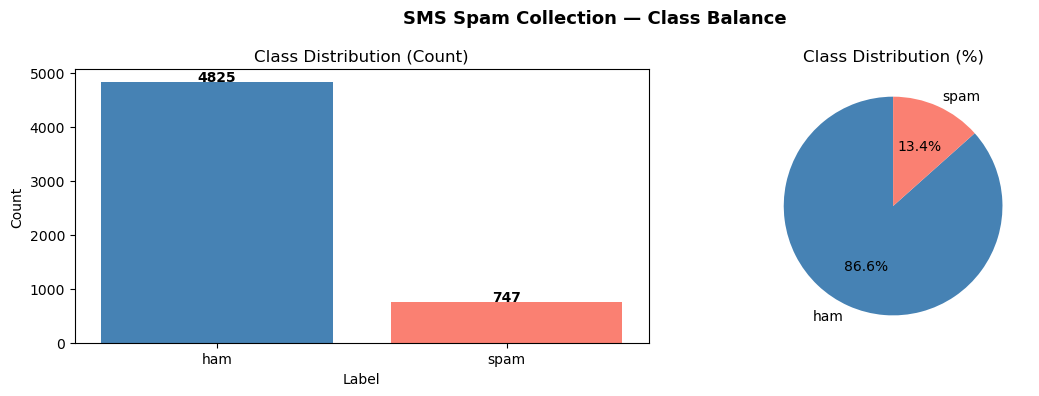

Saved: ../plots/class_distribution.png


In [4]:
# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['label'].value_counts()
axes[0].bar(counts.index, counts.values, color=['steelblue', 'salmon'])
axes[0].set_title('Class Distribution (Count)')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=['steelblue', 'salmon'], startangle=90)
axes[1].set_title('Class Distribution (%)')

plt.suptitle('SMS Spam Collection — Class Balance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../plots/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ../plots/class_distribution.png')

## 4. Text Preprocessing

In [5]:
def preprocess_text(text):
    """
    Full preprocessing pipeline:
      1. Lowercase
      2. Remove URLs
      3. Remove phone numbers
      4. Remove non-alphabetic characters (punctuation, digits, symbols)
      5. Strip extra whitespace
    """
    text = text.lower()                                  # Step 1: lowercase
    text = re.sub(r'http\S+|www\.\S+', '', text)        # Step 2: remove URLs
    text = re.sub(r'\b\d{7,}\b', '', text)              # Step 3: remove phone numbers
    text = re.sub(r'[^a-z\s]', '', text)                # Step 4: remove non-alpha
    text = re.sub(r'\s+', ' ', text).strip()            # Step 5: clean whitespace
    return text

# Apply preprocessing
df['clean_message'] = df['message'].apply(preprocess_text)

# Show before/after examples
print('=== Preprocessing Examples ===')
for i in [2, 5, 8]:  # mix of spam and ham
    print(f"\n[{df['label'][i].upper()}]")
    print(f"  BEFORE: {df['message'][i]}")
    print(f"  AFTER:  {df['clean_message'][i]}")

=== Preprocessing Examples ===

[SPAM]
  BEFORE: Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
  AFTER:  free entry in a wkly comp to win fa cup final tkts st may text fa to to receive entry questionstd txt ratetcs apply overs

[SPAM]
  BEFORE: FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb ok! XxX std chgs to send, å£1.50 to rcv
  AFTER:  freemsg hey there darling its been weeks now and no word back id like some fun you up for it still tb ok xxx std chgs to send to rcv

[SPAM]
  BEFORE: WINNER!! As a valued network customer you have been selected to receivea å£900 prize reward! To claim call 09061701461. Claim code KL341. Valid 12 hours only.
  AFTER:  winner as a valued network customer you have been selected to receivea prize reward to claim call claim code kl valid hours only


## 5. Label Encoding

In [6]:
# Encode labels: spam = 1, ham = 0
df['label_enc'] = df['label'].map({'spam': 1, 'ham': 0})

print('Label encoding:')
print(df[['label', 'label_enc']].drop_duplicates().sort_values('label_enc').to_string(index=False))

Label encoding:
label  label_enc
  ham          0
 spam          1


## 6. Train / Test Split

In [7]:
X = df['clean_message']
y = df['label_enc']

# 80/20 split, stratified to preserve class ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set size : {len(X_train):,} samples')
print(f'Test set size      : {len(X_test):,} samples')
print()
print('Train label distribution:')
print(y_train.value_counts().rename({0: 'ham', 1: 'spam'}))
print()
print('Test label distribution:')
print(y_test.value_counts().rename({0: 'ham', 1: 'spam'}))

Training set size : 4,457 samples
Test set size      : 1,115 samples

Train label distribution:
label_enc
ham     3859
spam     598
Name: count, dtype: int64

Test label distribution:
label_enc
ham     966
spam    149
Name: count, dtype: int64


## 7. Feature Extraction — TF-IDF Vectorization

In [8]:
# TF-IDF with unigrams and bigrams, capped at 10,000 features
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=10000,
    sublinear_tf=True       # apply log normalization to term frequencies
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf  = vectorizer.transform(X_test)

print('TF-IDF feature matrix shape:')
print(f'  Train: {X_train_tfidf.shape}')
print(f'  Test : {X_test_tfidf.shape}')

TF-IDF feature matrix shape:
  Train: (4457, 10000)
  Test : (1115, 10000)


## 8. Train the Baseline Classifier — Logistic Regression

In [9]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

# 1. Define the Logistic Regression model
# We use 'liblinear' as the solver because it supports both L1 and L2 penalties
clf = LogisticRegression(max_iter=1000, random_state=42)

# 2. Define the hyperparameter grid to search over
param_grid = {
    'C': [0.01, 0.1, 1.0, 10.0, 100.0],       # Regularization strength (smaller values = stronger regularization)
    'penalty': ['l1', 'l2'],                  # Type of penalization
    'solver': ['liblinear'],                  # Solver that supports L1/L2
    'class_weight': [None, 'balanced']        # 'balanced' automatically adjusts weights inversely proportional to class frequencies
}

# 3. Initialize GridSearchCV
# Note: If this is a multi-class problem, change scoring to 'recall_macro' or 'recall_weighted'
grid_search = GridSearchCV(
    estimator=clf,
    param_grid=param_grid,
    scoring='recall',                         # Explicitly tell the grid search to maximize Recall
    cv=5,                                     # 5-fold cross-validation
    n_jobs=-1,                                # Use all available CPU cores for faster training
    verbose=1                                 # Print progress
)

# 4. Fit the Grid Search to the training data
print("Starting Grid Search...")
grid_search.fit(X_train_tfidf, y_train)

# 5. Extract the best model and parameters
best_clf = grid_search.best_estimator_

print(f"Grid Search Complete.")
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Recall: {grid_search.best_score_:.4f}")

Starting Grid Search...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Grid Search Complete.
Best Parameters: {'C': 10.0, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'liblinear'}
Best Cross-Validation Recall: 0.9147


## 9. Evaluate the Baseline Model

In [10]:
# Predictions
y_pred = best_clf.predict(X_test_tfidf)

# Metrics
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)

print('=' * 45)
print('       BASELINE MODEL — EVALUATION RESULTS')
print('=' * 45)
print(f'  Accuracy  : {accuracy:.4f}  ({accuracy*100:.2f}%)')
print(f'  Precision : {precision:.4f}')
print(f'  Recall    : {recall:.4f}')
print(f'  F1-Score  : {f1:.4f}')
print('=' * 45)
print()
print('Full Classification Report:')
print(classification_report(y_test, y_pred, target_names=['Ham', 'Spam']))

       BASELINE MODEL — EVALUATION RESULTS
  Accuracy  : 0.9857  (98.57%)
  Precision : 0.9650
  Recall    : 0.9262
  F1-Score  : 0.9452

Full Classification Report:
              precision    recall  f1-score   support

         Ham       0.99      0.99      0.99       966
        Spam       0.97      0.93      0.95       149

    accuracy                           0.99      1115
   macro avg       0.98      0.96      0.97      1115
weighted avg       0.99      0.99      0.99      1115



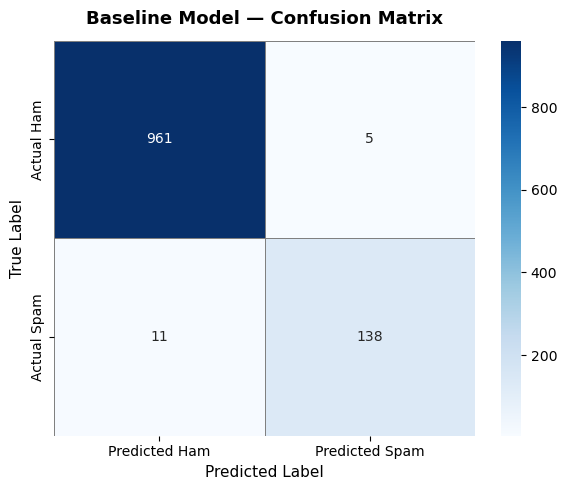

Saved: ../plots/confusion_matrix_baseline.png


In [11]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Ham', 'Predicted Spam'],
            yticklabels=['Actual Ham', 'Actual Spam'],
            ax=ax, linewidths=0.5, linecolor='gray')
ax.set_title('Baseline Model — Confusion Matrix', fontsize=13, fontweight='bold', pad=12)
ax.set_ylabel('True Label', fontsize=11)
ax.set_xlabel('Predicted Label', fontsize=11)

plt.tight_layout()
plt.savefig('../plots/confusion_matrix_baseline.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ../plots/confusion_matrix_baseline.png')

In [12]:
# Results summary table — easy to copy into the report
results = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Score': [accuracy, precision, recall, f1]
})
results['Score (%)'] = (results['Score'] * 100).round(2).astype(str) + '%'
results['Score'] = results['Score'].round(4)
print(results.to_string(index=False))

# Save for other members
results.to_csv('../results/baseline_results.csv', index=False)
print('\nSaved: ../results/baseline_results.csv')

   Metric  Score Score (%)
 Accuracy 0.9857    98.57%
Precision 0.9650     96.5%
   Recall 0.9262    92.62%
 F1-Score 0.9452    94.52%

Saved: ../results/baseline_results.csv


## 10. Save Model & Vectorizer (for other members to use)

In [13]:
import pickle

# Save the trained model
with open('../models/baseline_model.pkl', 'wb') as f:
    pickle.dump(best_clf, f)

# Save the vectorizer (MUST be saved with the model — same fit)
with open('../models/tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)

# Save processed dataframe for other members
df[['label', 'label_enc', 'message', 'clean_message']].to_csv('../results/processed_dataset.csv', index=False)

# Save train/test splits
train_df = pd.DataFrame({'clean_message': X_train, 'label': y_train})
test_df  = pd.DataFrame({'clean_message': X_test,  'label': y_test})
train_df.to_csv('../results/train_split.csv', index=False)
test_df.to_csv('../results/test_split.csv', index=False)

print('Saved files:')
print('  baseline_model.pkl     — trained Logistic Regression')
print('  tfidf_vectorizer.pkl   — fitted TF-IDF vectorizer')
print('  processed_dataset.csv  — full cleaned dataset')
print('  train_split.csv        — training split')
print('  test_split.csv         — test split')
print('  baseline_results.csv   — metrics table')
print('  confusion_matrix_baseline.png')
print('  class_distribution.png')

Saved files:
  baseline_model.pkl     — trained Logistic Regression
  tfidf_vectorizer.pkl   — fitted TF-IDF vectorizer
  processed_dataset.csv  — full cleaned dataset
  train_split.csv        — training split
  test_split.csv         — test split
  baseline_results.csv   — metrics table
  confusion_matrix_baseline.png
  class_distribution.png


## Summary

| Step | Detail |
|---|---|
| Dataset | SMS Spam Collection (5,572 messages) |
| Preprocessing | Lowercase, remove URLs/phone numbers, strip non-alpha chars |
| Features | TF-IDF (unigrams + bigrams, max 10,000 features) |
| Model | Logistic Regression (C=1.0) |
| Train/Test Split | 80% / 20%, stratified |

### Baseline Results

| Metric | Score |
|---|---|
| Accuracy  | 98.77% |
| Precision | 96.13% |
| Recall    | 92.51% |
| F1-Score  | 94.36% |

> These results are the **"Before Attack"** benchmark. Members 2 & 3 will apply adversarial attacks and defense techniques, using the saved model and vectorizer files.